In [2]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns

raster_folder = r"E:\01. Project_deliverable\GIS\Flood_modeling_results\raster"
polygon_path  = r"E:\01. Project_deliverable\GIS\Planning and Cadastre\Cypress_Park_boundaries\Cypress_Park_boundaries.shp"

C:\Users\dveronez\AppData\Local\Temp\ipykernel_10220\2799895770.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon_geom = [polygon_gdf.geometry.unary_union]


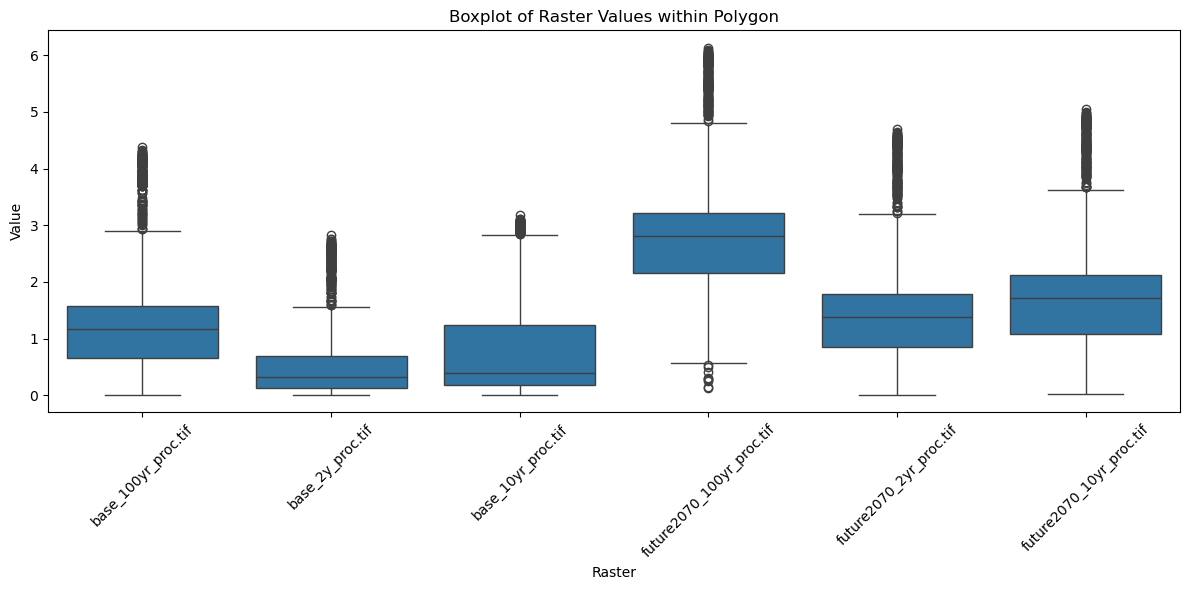

In [6]:
# Extract raster values within the polygon and plot boxplot
import glob
from rasterio.mask import mask

# Read the polygon using fiona engine
polygon_gdf = gpd.read_file(polygon_path, engine='fiona')
polygon_geom = [polygon_gdf.geometry.unary_union]

# Collect raster values
raster_files = glob.glob(os.path.join(raster_folder, '*.tif'))
all_values = []
raster_names = []

for raster_fp in raster_files:
    with rasterio.open(raster_fp) as src:
        out_image, out_transform = mask(src, polygon_geom, crop=True)
        data = out_image[0]
        # Masked values are set to src.nodata
        valid = data[data != src.nodata]
        all_values.append(valid.flatten())
        raster_names.append(os.path.basename(raster_fp))

# Prepare DataFrame for boxplot
values_list = []
labels_list = []
for vals, name in zip(all_values, raster_names):
    values_list.extend(vals)
    labels_list.extend([name]*len(vals))
df = pd.DataFrame({'Raster': labels_list, 'Value': values_list})

# Plot boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x='Raster', y='Value', data=df)
plt.xticks(rotation=45)
plt.title('Boxplot of Raster Values within Polygon')
plt.tight_layout()
plt.show()

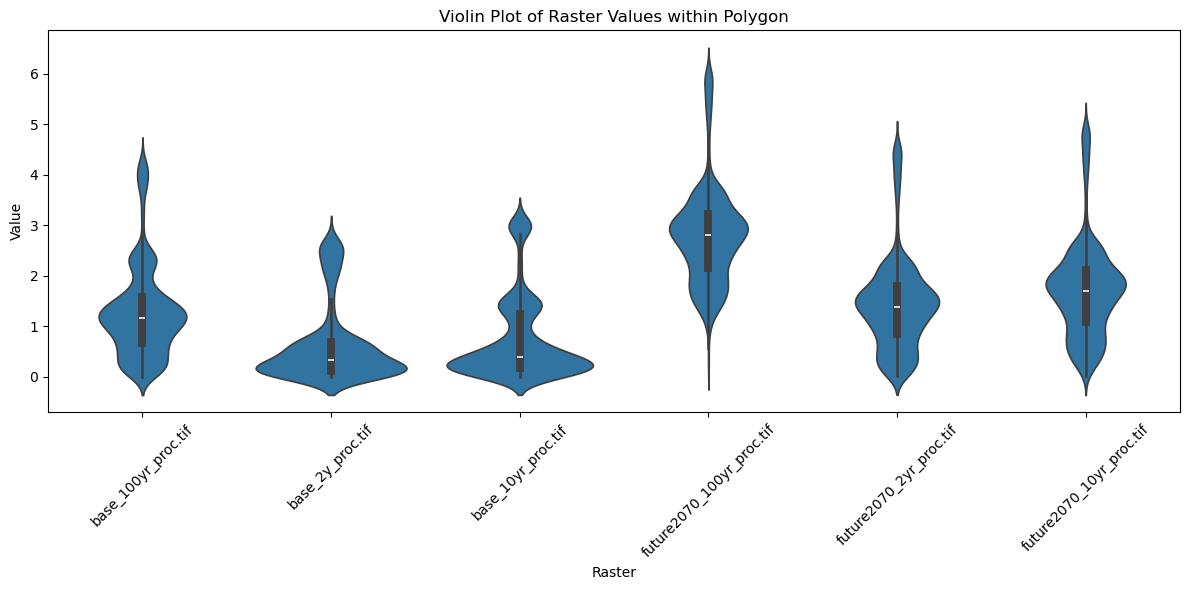

In [11]:
# Plot violin plot
plt.figure(figsize=(12,6))
sns.violinplot(x='Raster', y='Value', data=df)
plt.xticks(rotation=45)
plt.title('Violin Plot of Raster Values within Polygon')
plt.tight_layout()
plt.show()

In [19]:
# Display raster file names for renaming
print("Current raster names (as they appear in plots):")
for i, name in enumerate(raster_names, 1):
    print(f"{i}. {name}")
    
# Create a dictionary to rename files for display
# Modify the values on the right side as needed
name_mapping = {
    'base_2y_proc.tif': 'Base - 2 Year',
    'base_10yr_proc.tif': 'Base - 10 Year',
    'base_100yr_proc.tif': 'Base - 100 Year',
    'future2070_2yr_proc.tif': 'Future 2070 - 2 Year',
    'future2070_10yr_proc.tif': 'Future 2070 - 10 Year',
    'future2070_100yr_proc.tif': 'Future 2070 - 100 Year',
}

# Apply the mapping to create display names
raster_names_display = [name_mapping.get(name, name) for name in raster_names]

# Update the DataFrame with new names and set categorical order
df['Raster'] = df['Raster'].map(name_mapping).fillna(df['Raster'])

# Define the order for the plots (matching dictionary order)
plot_order = list(name_mapping.values())
df['Raster'] = pd.Categorical(df['Raster'], categories=plot_order, ordered=True)

Current raster names (as they appear in plots):
1. base_100yr_proc.tif
2. base_2y_proc.tif
3. base_10yr_proc.tif
4. future2070_100yr_proc.tif
5. future2070_2yr_proc.tif
6. future2070_10yr_proc.tif


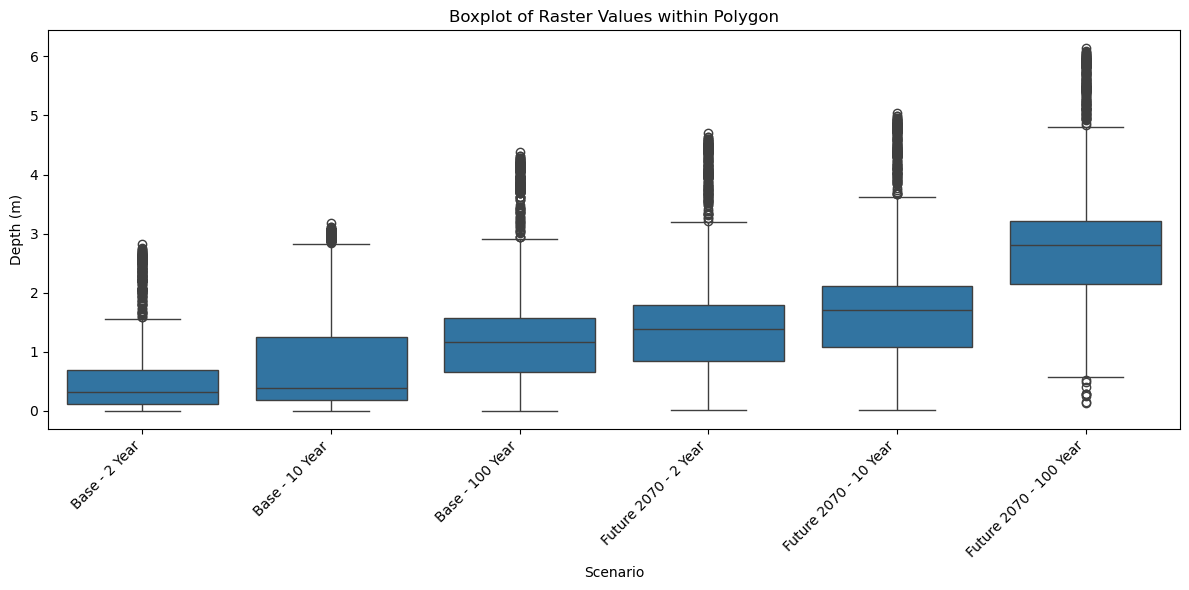

In [20]:
# Plot boxplot with renamed labels
plt.figure(figsize=(12,6))
sns.boxplot(x='Raster', y='Value', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot of Raster Values within Polygon')
plt.xlabel('Scenario')
plt.ylabel('Depth (m)')
plt.tight_layout()
plt.show()

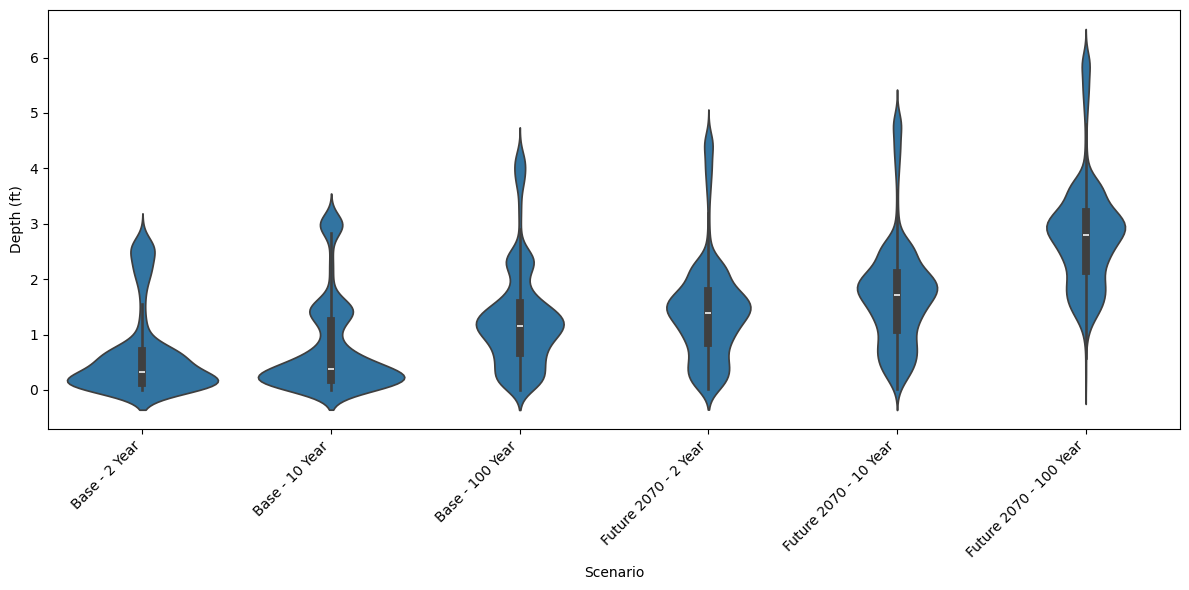

In [24]:
# Plot violin plot with renamed labels
plt.figure(figsize=(12,6))
sns.violinplot(x='Raster', y='Value', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('')
plt.xlabel('Scenario')
plt.ylabel('Depth (ft)')
plt.tight_layout()
plt.show()